**Cell 1:** Import necessary libraries and functions.

In [4]:
#Import necessary libraries and functions
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, medfilt
from scipy.signal import detrend
from scipy.interpolate import interp1d
from tqdm import tqdm
from skimage.registration import phase_cross_correlation
from scipy.ndimage import fourier_shift
import gc
import os
import re
from pathlib import Path

In [20]:
# VIDEO: Change filepath to location of the video and its metadata
baseFolder = '/Volumes/CNSLabData/coneLab/liveTests/'
animalName = 'L1F1'
expName = 'dw_six_20260511'
logic_sample_rate  = 20_000  # in Hz
fps = 50 # in Hz

# STIMULUS: Parameters
stim_on_s = 0.25         # seconds stimulus ON (per pulse)
pre_window = 0.5        # seconds to include before stimulus onset
post_window = 0.25        # seconds to include after stimulus onset
cond_names = ["top_right", "top_middle", "top_left", 
              "bottom_right", "bottom_middle", "bottom_left"] # grating screen locations
cond_order = np.array([0, 1, 2, 3, 4, 5], dtype=int)  # order of conditions presented (0-indexed)

# SPATIAL BINNING: Set to integer > 1 to enable spatial binning
tile_rows, tile_cols = 128, 128  # size of tiles for spatial binning  

baseFile = os.path.join(baseFolder, animalName, expName, animalName + '_' + expName)
metadataFile = baseFile + '.npy'
videoFile = baseFile + '.bin'
logicFile = baseFile

vid_metadata = np.load(metadataFile, allow_pickle=True).item()
# LOGIC ANALYZER: Change filepath to location of the logic analyzer data
logic_folder = os.path.join(logicFile + '_unzip')
logic_pattern = "logic-1-*"


**Cell 2:** Load the video and metadata info by putting in the file paths to the video .bin file and its corresponding metadata.npy file.

In [22]:
# Extract the following data from the metadata
n_frames = vid_metadata['num_frames']
frame_width = vid_metadata['frame_width']
frame_height = vid_metadata['frame_height']
data_type = vid_metadata['data_type']
frame_timestamps = vid_metadata['frame_timestamps']
sys_timestamps = vid_metadata['sys_clock_timestamps']
frame_shape = (frame_height, frame_width)

# Spatial binning
tile_height = frame_shape[0] // tile_rows   
tile_width = frame_shape[1] // tile_cols   

# Compute total number of bytes in video file
frame_bytes = np.prod(frame_shape) * np.dtype(data_type).itemsize

print(f"Total frames: {n_frames}")

Total frames: 23066


**Cell 3:** Load the logic analyzer data by putting in the file path of the logic analyzer data corresponding to the video .bin and metadata.npy file in cell 2. Change the sample_rate to what's stated in the logic analyzer metadata .txt file.

In [23]:
def load_logic_folder(folder, pattern, sample_rate):

    folder = Path(folder)
    files = sorted(
        folder.glob(pattern),
        key=lambda f: int(re.search(r"logic-1-(\d+)", f.name).group(1))
    )    
    assert len(files) > 0, "No logic files found"

    data = np.concatenate([np.fromfile(f, dtype=np.uint8) for f in files])
    array = np.unpackbits(data[:, None], axis=1, bitorder='little')
    t = np.arange(array.shape[0]) / sample_rate

    return t, array

logic_t, logic_array = load_logic_folder(logic_folder, logic_pattern, logic_sample_rate)

**Cell 4 (1):** Performs motion correction using the first $x$ number of frames in the video. Change this number of reference frames given by the variable n_ref_frames. Currently only performs motion correction in x and y direction (i.e. no rotations) using phase cross correlation and fourier transforms. After motion correction, spatial binning is performed (the original 2048x2048 is binned to 128x128). This cell is the less efficient and slower method which doesn't load the video into memory if sufficient memory is a concern. If enough memory, use Cell 4 (2) for more efficient processing.

In [25]:
# Lists for storing shifts and reference frames
reference_stack = []
x_shifts = []
y_shifts = []

# Choose the number of reference frames to use for motion correction
n_ref_frames = 50

# Read the binary video file and extract reference frames
with open(videoFile, 'rb') as f:
    for _ in range(n_ref_frames):
        frame_data = f.read(frame_bytes)
        if len(frame_data) < frame_bytes:
            break
        frame = np.frombuffer(frame_data, dtype=data_type).reshape(frame_shape).astype(np.float32)
        reference_stack.append(frame)

# Compute the mean of the reference frames
reference_frame = np.mean(np.stack(reference_stack), axis=0)

# Initialize arrays to store tile means
tile_means = np.zeros((n_frames, tile_rows * tile_cols), dtype=np.float32)

# Perform motion correction and compute tile means
with open(videoFile, 'rb') as f:
    for i in tqdm(range(n_frames), desc="Motion correcting frames", unit="frame"):
        frame_data = f.read(frame_bytes)
        if len(frame_data) < frame_bytes:
            print(f"Incomplete frame at index {i}, skipping.")
            break

        frame = np.frombuffer(frame_data, dtype=data_type).reshape(frame_shape).astype(np.float32)

        shift, error, diffphase = phase_cross_correlation(reference_frame, frame, upsample_factor=1)
        y_shifts.append(shift[0])
        x_shifts.append(shift[1])

        shifted_frame = np.fft.ifftn(fourier_shift(np.fft.fftn(frame), shift)).real

        tile_idx = 0
        for row in range(0, frame_shape[0], tile_height):
            for col in range(0, frame_shape[1], tile_width):
                tile = shifted_frame[row:row+tile_height, col:col+tile_width]

                if np.isnan(tile).any():
                    tile_mean = np.nanmean(tile)
                    if np.isnan(tile_mean):
                        tile_mean = 0.0
                else:
                    tile_mean = tile.mean()

                tile_means[i, tile_idx] = tile_mean
                tile_idx += 1

Motion correcting frames: 100%|██████████████████████████████████████████████████████████████████████████████████████| 23066/23066 [25:21<00:00, 15.16frame/s]


**Cell 4 (2):** Performs motion correction using the first $x$ number of frames in the video. Change this number of reference frames given by the variable n_ref_frames. Currently only performs motion correction in x and y direction (i.e. no rotations) using phase cross correlation and fourier transforms. After motion correction, spatial binning is performed (the original 2048x2048 is binned to 128x128). Use this cell if RAM allows it.

In [12]:
# with open(filepath, 'rb') as f:
#     data = np.frombuffer(f.read(), dtype=data_type)
# frames = data.reshape((n_frames, frame_height, frame_width)).astype(np.float32)

# reference_frame = frames[:50].mean(axis=0)

# tile_h, tile_w = tile_height, tile_width
# tile_rows = frame_height // tile_h
# tile_cols = frame_width // tile_w
# tile_means = np.zeros((n_frames, tile_rows * tile_cols), dtype=np.float32)

# x_shifts, y_shifts = [], []

# def compute_tile_means(frame, tile_h, tile_w):
#     h, w = frame.shape
#     frame = frame[:h - h % tile_h, :w - w % tile_w]  # Ensure divisible
#     reshaped = frame.reshape(h // tile_h, tile_h, w // tile_w, tile_w)
#     tile_means = reshaped.mean(axis=(1, 3))
#     return tile_means.ravel()

# for i in tqdm(range(n_frames), desc="Motion correcting frames", unit="frame"):
#     frame = frames[i]
#     shift, error, diffphase = phase_cross_correlation(reference_frame, frame, upsample_factor=1)
#     y_shifts.append(shift[0])
#     x_shifts.append(shift[1])
#     shifted_frame = np.fft.ifftn(fourier_shift(np.fft.fftn(frame), shift)).real
#     tile_means[i] = compute_tile_means(shifted_frame, tile_h, tile_w)

# del frames
# gc.collect()


**Cell 5:** Performs hemodynamic correction by interpolating the violet (405nm), detrending both blue (470nm) and violet, then using least squares method to perform linear regression. The coefficient map and $R^2$ map is also created for visualization. 

In [26]:
# Separate the 405 nm and 470 nm LED data (depending on the video, these may swap)
led1_idx = np.arange(0, len(tile_means), 2)  # 405 nm
led2_idx = np.arange(1, len(tile_means), 2)  # 470 nm

# Ensure both LED indices are of the same length
if len(led1_idx) > len(led2_idx):
    led1_idx = led1_idx[:-1] 

# Create time vectors for the 405nm and 470nm data
t_1 = led1_idx/fps
t_2 = led2_idx/fps

# Use the LED indices to extract the corresponding intensity data
F_470 = tile_means[led1_idx]
F_405_raw = tile_means[led2_idx]

# Initialize the interpolated 405 nm data
F_405_interp = np.zeros_like(F_470)

# Interpolate the 405 nm data to match the 470 nm time vector
for tile in range(F_470.shape[1]):
    interp_func = interp1d(t_1, F_405_raw[:, tile], kind='linear', fill_value='extrapolate')
    F_405_interp[:, tile] = interp_func(t_2)

# Apply median filtering to the 470 nm and interpolated 405 nm data
filtered_470 = np.apply_along_axis(medfilt, 0, F_470, kernel_size=9)
filtered_405 = np.apply_along_axis(medfilt, 0, F_405_interp, kernel_size=9)

# Initialize arrays for corrected data, coefficients, and detrended data (photobleaching correction)
F_corrected = np.zeros_like(F_470)
fitted_470 = np.zeros_like(F_470)
fitted_405 = np.zeros_like(F_405_interp)   
detrended_470 = np.zeros_like(F_470)
detrended_405 = np.zeros_like(F_405_interp)   

# Initialize arrays for F0, coefficients, and R^2 values
F0 = np.zeros(F_405_interp.shape[1])  # correct shape (tile,)
coeff_map = np.zeros((tile_rows * tile_cols, 1), dtype=np.float32)
r2_map = np.zeros((tile_rows * tile_cols, 1), dtype=np.float32)

# Loop through each tile to compute F0, coefficients, and corrected fluorescence
for tile in range(F_470.shape[1]):
    y = filtered_470[:, tile]
    x = filtered_405[:, tile]

    F0[tile] = np.nanmean(y[0:49])

    x = detrend(x)
    y = detrend(y)
    detrended_470[:, tile] = y
    detrended_405[:, tile] = x

    A = np.vstack([x, np.ones_like(x)]).T
    beta, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
    coeff_map[tile] = beta
    r2 = 1 - np.sum((y - (beta * x + intercept))**2) / np.sum((y - np.mean(y))**2)
    r2_map[tile] = r2
    F_corrected[:, tile] = y - beta * x + F0[tile]

    fitted_405[:, tile] = beta * x + intercept + F0[tile]

# Calculate dF/F for the 470 nm and 405 nm data
F0[F0 == 0] = np.nan
dFoF_470_corrected = (F_corrected - F0) / F0
dFoF_470_corrected = np.nan_to_num(dFoF_470_corrected, nan=0.0)
dFoF_470 = (F_470 - F0) / F0
dFoF_470 = np.nan_to_num(dFoF_470, nan=0.0)
dFoF_405 = (F_405_interp - F0) / F0
dFoF_405 = np.nan_to_num(dFoF_405, nan=0.0)

**Cell 6:** Plotting instructions to see the coefficient and $R^2$ maps resulting from linear regression and least squares between 470nm and 405nm signals.

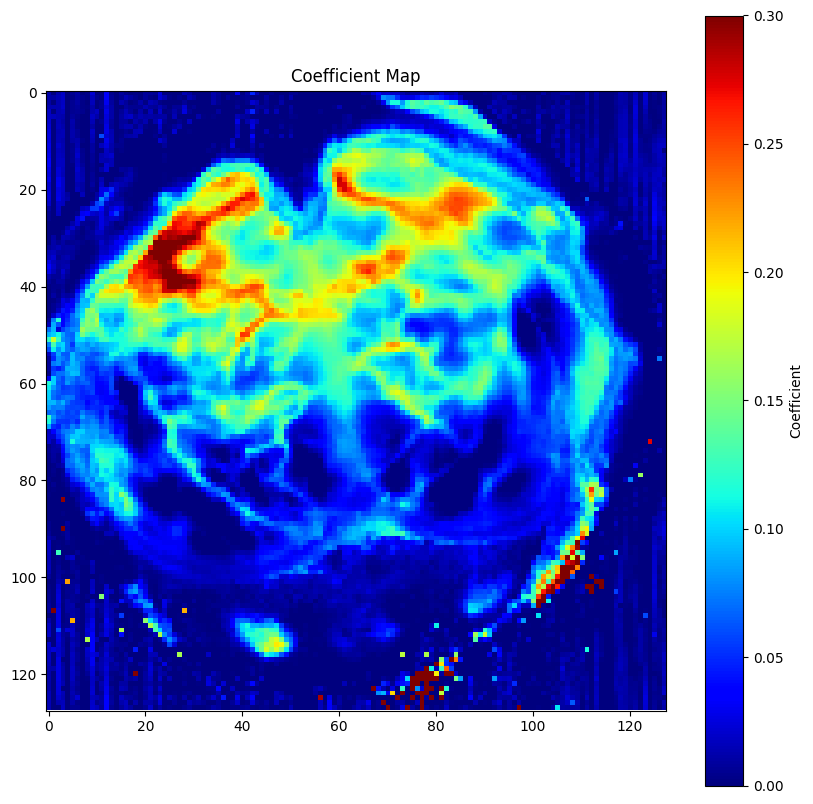

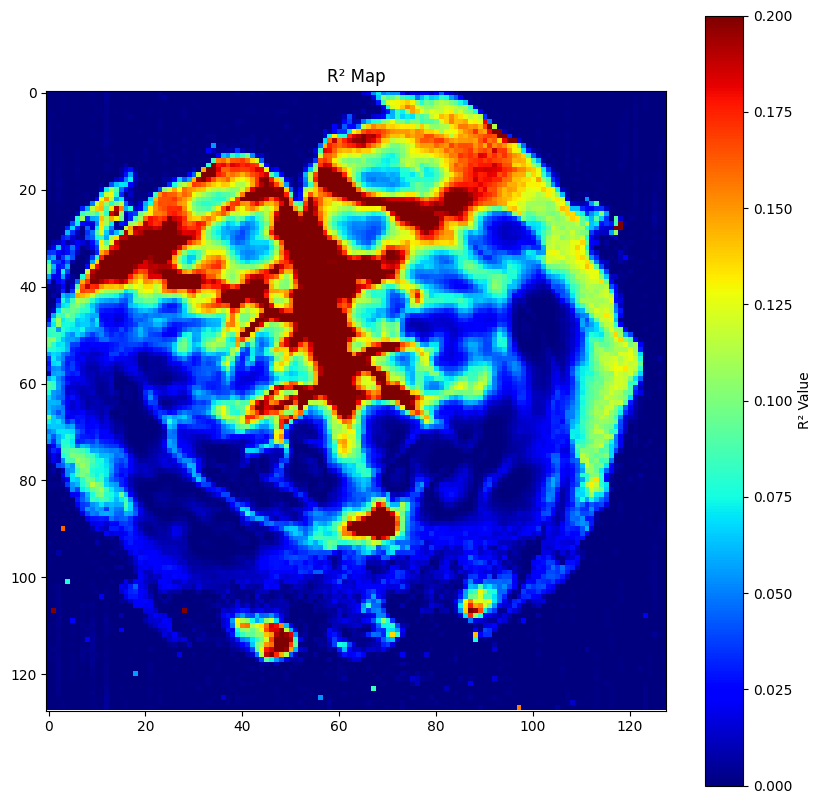

In [31]:
# Plot the coefficient map
plt.figure(figsize=(10, 10))
plt.imshow(coeff_map.reshape(tile_rows, tile_cols), cmap='jet', aspect='equal')
plt.clim(vmin=0, vmax=0.3)
plt.colorbar(label='Coefficient')
plt.title('Coefficient Map')

# Plot the R^2 map
plt.figure(figsize=(10, 10))
plt.imshow(r2_map.reshape(tile_rows, tile_cols), cmap='jet', aspect='equal')
plt.colorbar(label='R² Value')
plt.clim(vmin=0, vmax=0.2)
plt.title('R² Map')
plt.show()

**Cell 7:** Plotting instructions to see the strobe and visual stim signal from logic analyzer. Use this plot to determine visual_start and visual_end in Cell 8 for synchronization of the video and logic analyzer data by playing around with xlim to see clearly. Note - visual stim is on when signal is 0 and off when signal is 1 (anti-intuitive); applies for the rest of the plots that include this signal.

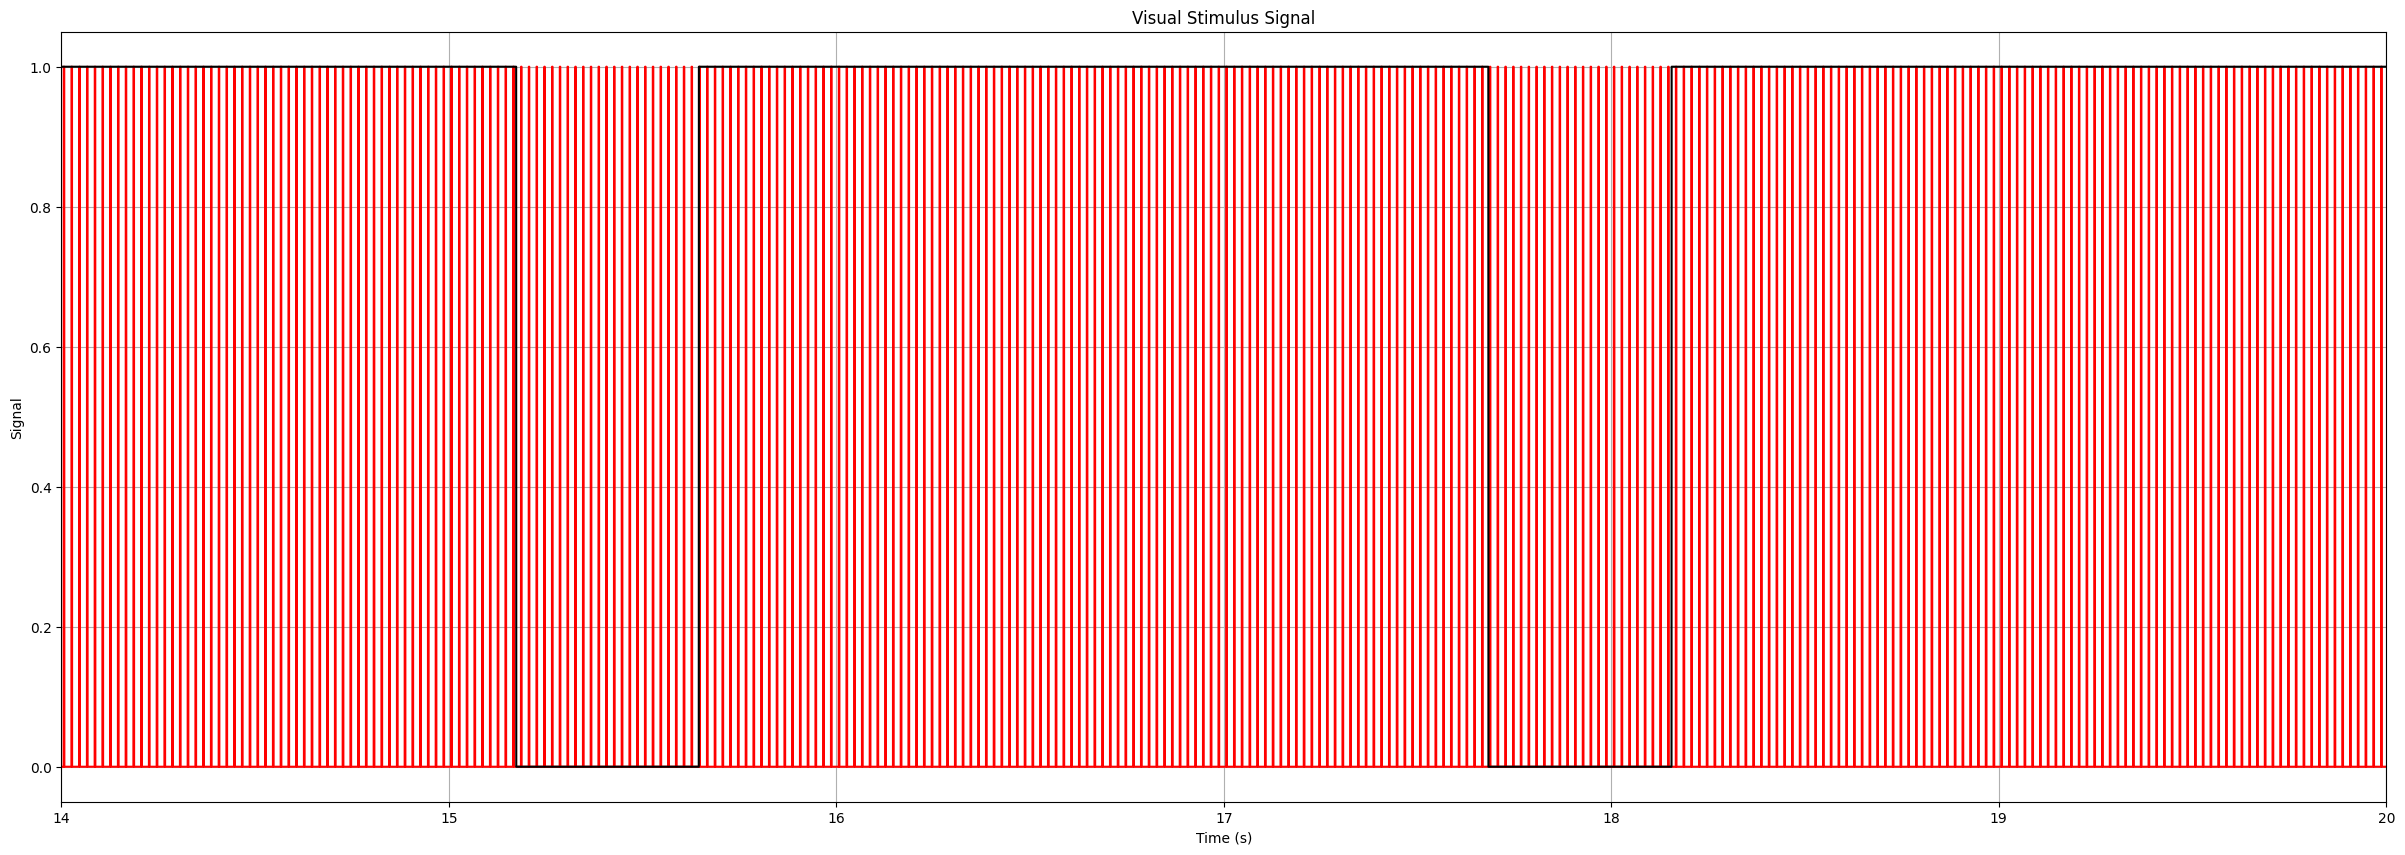

In [70]:
strobeChannel = 3
stimChannel = 2
# Plot the strobe and visual stimulus signal from the logic analyzer
plt.figure(figsize=(30, 10))
plt.plot(logic_t[logic_t > 1], logic_array[:, strobeChannel][logic_t > 1], 'r', label='Strobe')
plt.plot(logic_t[logic_t > 1], logic_array[:, stimChannel][logic_t > 1], 'k', label='Stimulus')
plt.xlabel("Time (s)")
plt.ylabel("Signal")
plt.title("Visual Stimulus Signal")
plt.grid(True)
plt.xlim(14, 20)
plt.show()

# Note: Cam/strobe signal begins after first peak of visual stim signal, then the photodiode square appears after half the amount of experiment delay time elapses. 
# Visual stim is on when stim signal is 0, and off when stim signal is 1.
# Therefore, the first presentation of visual stimuli is after the equal on/off period (i.e. experiment delay) at the beginning.

**Cell 8:** Using the determined visual_start and visual_end previously, change the variables in the following cell which allows for computation and synchronization of video and logic analyzer data. Note - you need to change the baseline_length variable depending on what it was set to for the experiment.

In [117]:
strobe = logic_array[:, strobeChannel].astype(np.uint8)
visual_stimulus = logic_array[:, stimChannel].astype(np.uint8)  # active-low: 0 = ON

# ON edges: 1->0, OFF edges: 0->1
stim_starts = np.flatnonzero((visual_stimulus[:-1] == 1) & (visual_stimulus[1:] == 0)) + 1
stim_ends   = np.flatnonzero((visual_stimulus[:-1] == 0) & (visual_stimulus[1:] == 1)) + 1

# Pair each start with the next end
pairs = []
j = 0
for s in stim_starts:
    while j < len(stim_ends) and stim_ends[j] < s:
        j += 1
    if j < len(stim_ends):
        pairs.append((s, stim_ends[j]))

pairs = np.array(pairs)
if len(pairs) == 0:
    raise RuntimeError("No valid start/end pairs.")

dur_s = (pairs[:,1] - pairs[:,0]) / logic_sample_rate

# Keep only low segments that look like real stim pulses (~2 s)
target_on_s = 0.5
tol_s = 0.2  # allow 1.5–2.5 s; adjust if needed
good = (dur_s > (target_on_s - tol_s)) & (dur_s < (target_on_s + tol_s))

pairs = pairs[good]
stim_starts = pairs[:,0]   # one onset per real low segment
stim_ends   = pairs[:,1]
print("Kept", len(stim_starts), "stim pulses after duration filter.")


if len(stim_starts) == 0 or len(stim_ends) == 0:
    raise RuntimeError("No stimulus edges found. Check channel index and whether stimulus is active-low/high.")

stim_start_idx = stim_starts[0]     # first pulse starts
stim_end_idx   = stim_ends[-1]      # last pulse ends

check_strobe = np.arange(stim_start_idx, stim_end_idx + 1)

strobe_edges = np.where((strobe[1:] == 1) & (strobe[:-1] == 0))[0] + 1  # +1 to align index

if len(strobe_edges) == 0:
    print("No rising edges detected in strobe signal.")
else:
    first_frame = strobe_edges[0] / logic_sample_rate  # seconds

    stim_frame_edges = np.where((strobe[check_strobe[1:]] == 1) & (strobe[check_strobe[:-1]] == 0))[0]

    if len(stim_frame_edges) == 0:
        print("No rising strobe edges during visual stimulus found.")
    else:
        baseline_length = 1 #seconds; adjust as needed
        first_stim_edge = check_strobe[stim_frame_edges[0] + 1]  # +1 because [1:] above
        last_stim_edge = check_strobe[stim_frame_edges[-1] + 1]
        stim_start_time = first_stim_edge / logic_sample_rate  # seconds
        stim_end_time = last_stim_edge / logic_sample_rate + baseline_length  # seconds
        stim_strobe_duration = stim_end_time - stim_start_time + baseline_length # seconds
        offset = stim_start_time - first_frame

        print("The following times are with respect to the start of the logic analyzer recording...")
        print(f"First strobe edge (video start): {first_frame:.3f} s")
        print(f"First strobe during visual stimulus: {stim_start_time:.3f} s")
        print(f"Last strobe during visual stimulus: {stim_end_time:.3f} s")
        print(f"Strobe duration during visual stimulus: {stim_strobe_duration:.3f} s")
        print(f"Offset (stimulus delay after video start): {offset:.3f} s")

        # 1) Stimulus ON times from photodiode edges (logic time)
        stim_on_times_logic = stim_starts / logic_sample_rate  # seconds since logic start

        # 2) Convert to video time: video t=0 at first strobe edge
        stim_on_times_video = stim_on_times_logic - first_frame

        # 3) Keep only onsets that exist in the video timebase
        # (prevents chopping off a full repeat due to strobe-window mismatch)
        stim_on_times_video = stim_on_times_video[
            (stim_on_times_video >= 0) &
            (stim_on_times_video <= t_2[-1])
        ]

        # 4) Label into 6 conditions assuming fixed cyclic order
        cond_order = np.array([0, 1, 2, 3, 4, 5])  # edit if your true order differs

        N = len(stim_on_times_video)
        print("Detected onsets inside video:", N)

        if N < 6:
            raise RuntimeError("Not enough onsets detected to label 6 conditions.")

        # Trim to a multiple of 6 so repeats are complete
        N_use = (N // 6) * 6
        stim_on_times_video = stim_on_times_video[:N_use]

        stim_ids = np.tile(cond_order, N_use // 6)
        assert len(stim_ids) == len(stim_on_times_video)

        print("Using", N_use // 6, "repeats (total onsets:", N_use, ")")

Kept 180 stim pulses after duration filter.
The following times are with respect to the start of the logic analyzer recording...
First strobe edge (video start): 10.106 s
First strobe during visual stimulus: 15.186 s
Last strobe during visual stimulus: 465.459 s
Strobe duration during visual stimulus: 451.273 s
Offset (stimulus delay after video start): 5.080 s
Detected onsets inside video: 180
Using 30 repeats (total onsets: 180 )


In [118]:
on = stim_on_times_video[4]
sel = np.where((t_2 >= on) & (t_2 < on + stim_on_s))[0]
print("First onset:", on)
print("Selected frames:", len(sel))
print("First/last selected t_2:", t_2[sel[0]], t_2[sel[-1]])


First onset: 15.08855
Selected frames: 6
First/last selected t_2: 15.1 15.3


In [119]:
# Create a dictionary to store responses for each condition
condition_responses = {name: [] for name in cond_names}
condition_responses_pre = {name: [] for name in cond_names}
condition_times = {name: [] for name in cond_names}

# For each stimulus onset, extract the response window
for onset_time, cond_id in zip(stim_on_times_video, stim_ids):
    cond_name = cond_names[cond_id]
    
    # Find frames within the window around this stimulus
    window_mask = (t_2 >= onset_time) & (t_2 <= onset_time + post_window)
    window_mask_pre = (t_2 >= onset_time - pre_window) & (t_2 <= onset_time)
    
    # Get the dF/F data for this window
    window_data = dFoF_470_corrected[window_mask, :]
    window_data_pre = dFoF_470_corrected[window_mask_pre, :]
    
    # Get the time points relative to stimulus onset
    window_times = t_2[window_mask] - onset_time
    
    # Store the response and times
    condition_responses[cond_name].append(window_data)
    condition_responses_pre[cond_name].append(window_data)
    condition_times[cond_name].append(window_times)

# Average across repetitions for each condition
avg_responses = {}
avg_responses_pre = {}
std_responses = {}
time_vectors = {}

for cond_name in cond_names:
    if condition_responses[cond_name]:  # Check if we have data for this condition
        # Stack all repetitions for this condition
        all_responses = np.stack(condition_responses[cond_name])
        all_responses_pre = np.stack(condition_responses_pre[cond_name])
        
        # Average across repetitions
        avg_responses[cond_name] = np.mean(all_responses, axis=0)
        avg_responses_pre[cond_name] = np.mean(all_responses_pre, axis=0)
        std_responses[cond_name] = np.std(all_responses, axis=0)
        
        # Use the first time vector (all should be the same)
        time_vectors[cond_name] = condition_times[cond_name][0]
        
        print(f"Condition '{cond_name}': {len(condition_responses[cond_name])} repetitions, {avg_responses[cond_name].shape[0]} frames per repetition")

ValueError: all input arrays must have the same shape

In [113]:
%matplotlib widget
# For ROI coordinate selection
img = dFoF_470_corrected.reshape(dFoF_470_corrected.shape[0], tile_rows, tile_cols)
img = np.mean(img,axis=0)

plt.imshow(img, cmap='gray')

print("Click on the image...")

# Wait for 1 click (set n=-1 for unlimited until Enter)
points = plt.ginput(n=1)

print("Selected point(s):", points)

plt.show()


Click on the image...


/var/folders/tz/0kz5pc0x641dhdr0b9yn7ddw0000gp/T/ipykernel_87582/2399150344.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  points = plt.ginput(n=1)


Selected point(s): []


/var/folders/tz/0kz5pc0x641dhdr0b9yn7ddw0000gp/T/ipykernel_87582/2399150344.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [114]:
# Plot 1: Average time course for specific channels for each condition
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

# Use the same channel indices as before
channel_indices = [5160, 5205, 9000, 7770, 12220, 10970]
labels = ['Left Anterior', 'Right Anterior', 'Left Mid', 'Right Mid', 'Left Posterior', 'Right Posterior']

for idx, (channel_idx, label) in enumerate(zip(channel_indices, labels)):
    ax = axes[idx]
    
    for cond_name in cond_names:
        if cond_name in avg_responses:
            avg_response = avg_responses[cond_name][:, channel_idx]-np.mean(avg_responses_pre[cond_name][:, channel_idx], axis=0)
            std_response = std_responses[cond_name][:, channel_idx]
            times = time_vectors[cond_name]
            
            # Plot mean ± SEM
            # sem = std_response / np.sqrt(len(condition_responses[cond_name]))
            ax.plot(times, avg_response, label=cond_name)
            # ax.fill_between(times, avg_response - sem, avg_response + sem, alpha=0.2)
    
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, label='Stim Onset')
    ax.axvline(x=stim_on_s, color='k', linestyle=':', alpha=0.5, label='Stim Offset')
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('dF/F')
    ax.set_title(f'{label} - Tile {channel_idx}')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

/var/folders/tz/0kz5pc0x641dhdr0b9yn7ddw0000gp/T/ipykernel_87582/3739252106.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


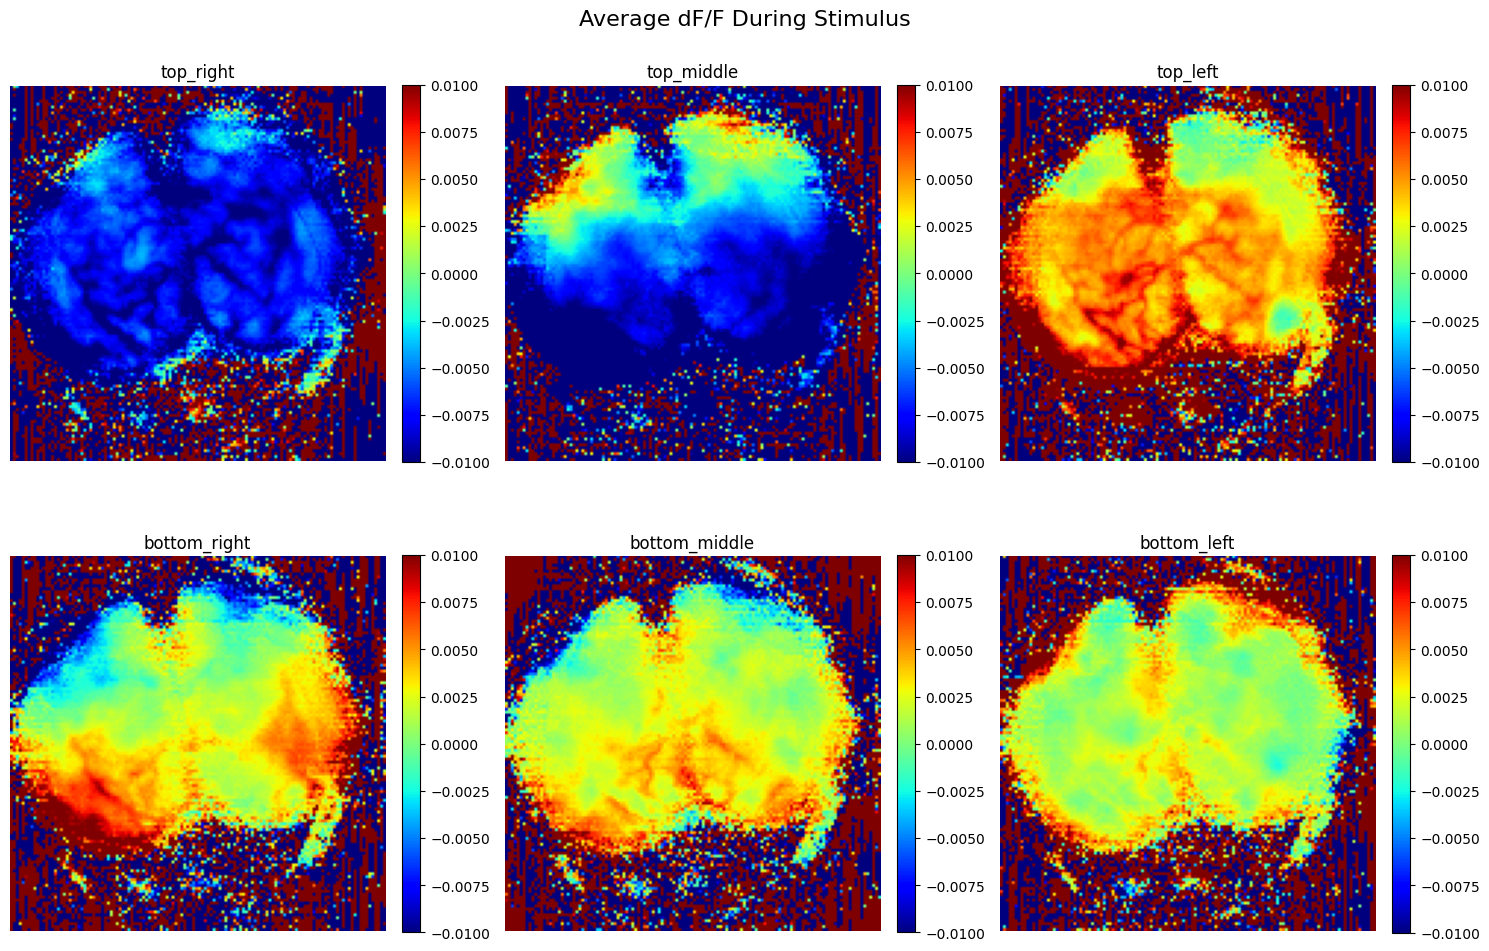

In [91]:
# Plot 2: Average dF/F maps for each condition (mean response during stimulus)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, cond_name in enumerate(cond_names):
    if cond_name in avg_responses:
        # Find frames during stimulus (0 to stim_on_s)
        stim_mask = (time_vectors[cond_name] >= 0) & (time_vectors[cond_name] <= stim_on_s)
        
        # Average dF/F during stimulus period
        avg_during_stim = np.mean(avg_responses[cond_name][stim_mask, :], axis=0)
        avg_map = avg_during_stim.reshape(tile_rows, tile_cols)
        
        # Plot
        im = axes[idx].imshow(avg_map, cmap='jet', aspect='equal', 
                              vmin=-0.01, vmax=0.01)  # Adjust vmin/vmax as needed
        axes[idx].set_title(f'{cond_name}')
        axes[idx].axis('off')
        
        # Add colorbar
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
        fig.suptitle("Average dF/F During Stimulus", fontsize=16)

plt.tight_layout()
plt.show()


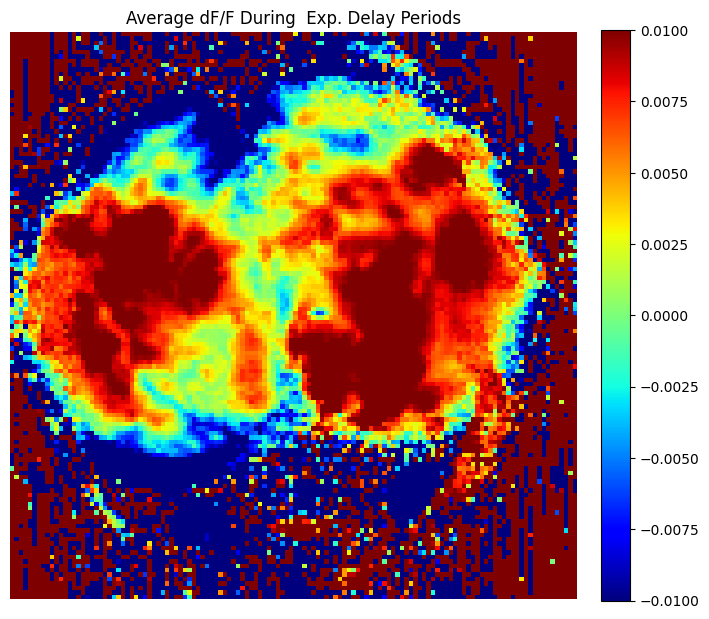

In [66]:
# Use first 10s AND last 10s as combined baseline
baseline_duration = 10.0  # seconds

# Find frames within the first 10 seconds
first_baseline_mask = t_2 <= baseline_duration

# Find frames within the last 10 seconds
last_baseline_mask = t_2 >= (t_2[-1] - baseline_duration)

# COMBINED: frames in first 10s OR last 10s
baseline_mask = first_baseline_mask | last_baseline_mask

# Calculate average dF/F during combined baseline period
baseline_avg = np.mean(dFoF_470_corrected[baseline_mask, :], axis=0)

# Reshape for plotting
baseline_map = baseline_avg.reshape(tile_rows, tile_cols)

# Plot
plt.figure(figsize=(8, 8))
im = plt.imshow(baseline_map, cmap='jet', aspect='equal', vmin=-0.01, vmax=0.01)  # Adjust vmin/vmax as needed
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title(f'Average dF/F During  Exp. Delay Periods')
plt.axis('off')
plt.show()


**Cell 9:** Create masks for plotting the time based on the synchronization calculations in Cell 8.

In [92]:
# Masks for alignment of visual stim and video
mask = (t_2 >= offset) & (t_2 <= (offset + stim_strobe_duration))
logic_mask = (logic_t >= stim_start_time) & (logic_t <= stim_end_time)

**Cell 10:** Setting parameters for the usage of scipy.lfilter on intensity signals. 

In [93]:
# Size of moving average window
window_size = 5

# Numerator coefficient vector in 1-D space
b = np.ones(window_size) / window_size

# Denominator coefficient vector in 1-D space
a = 1

**Cell 12:** Plotting instructions to see the corrected dFoF 470nm signal for various locations across the brain for comparison.

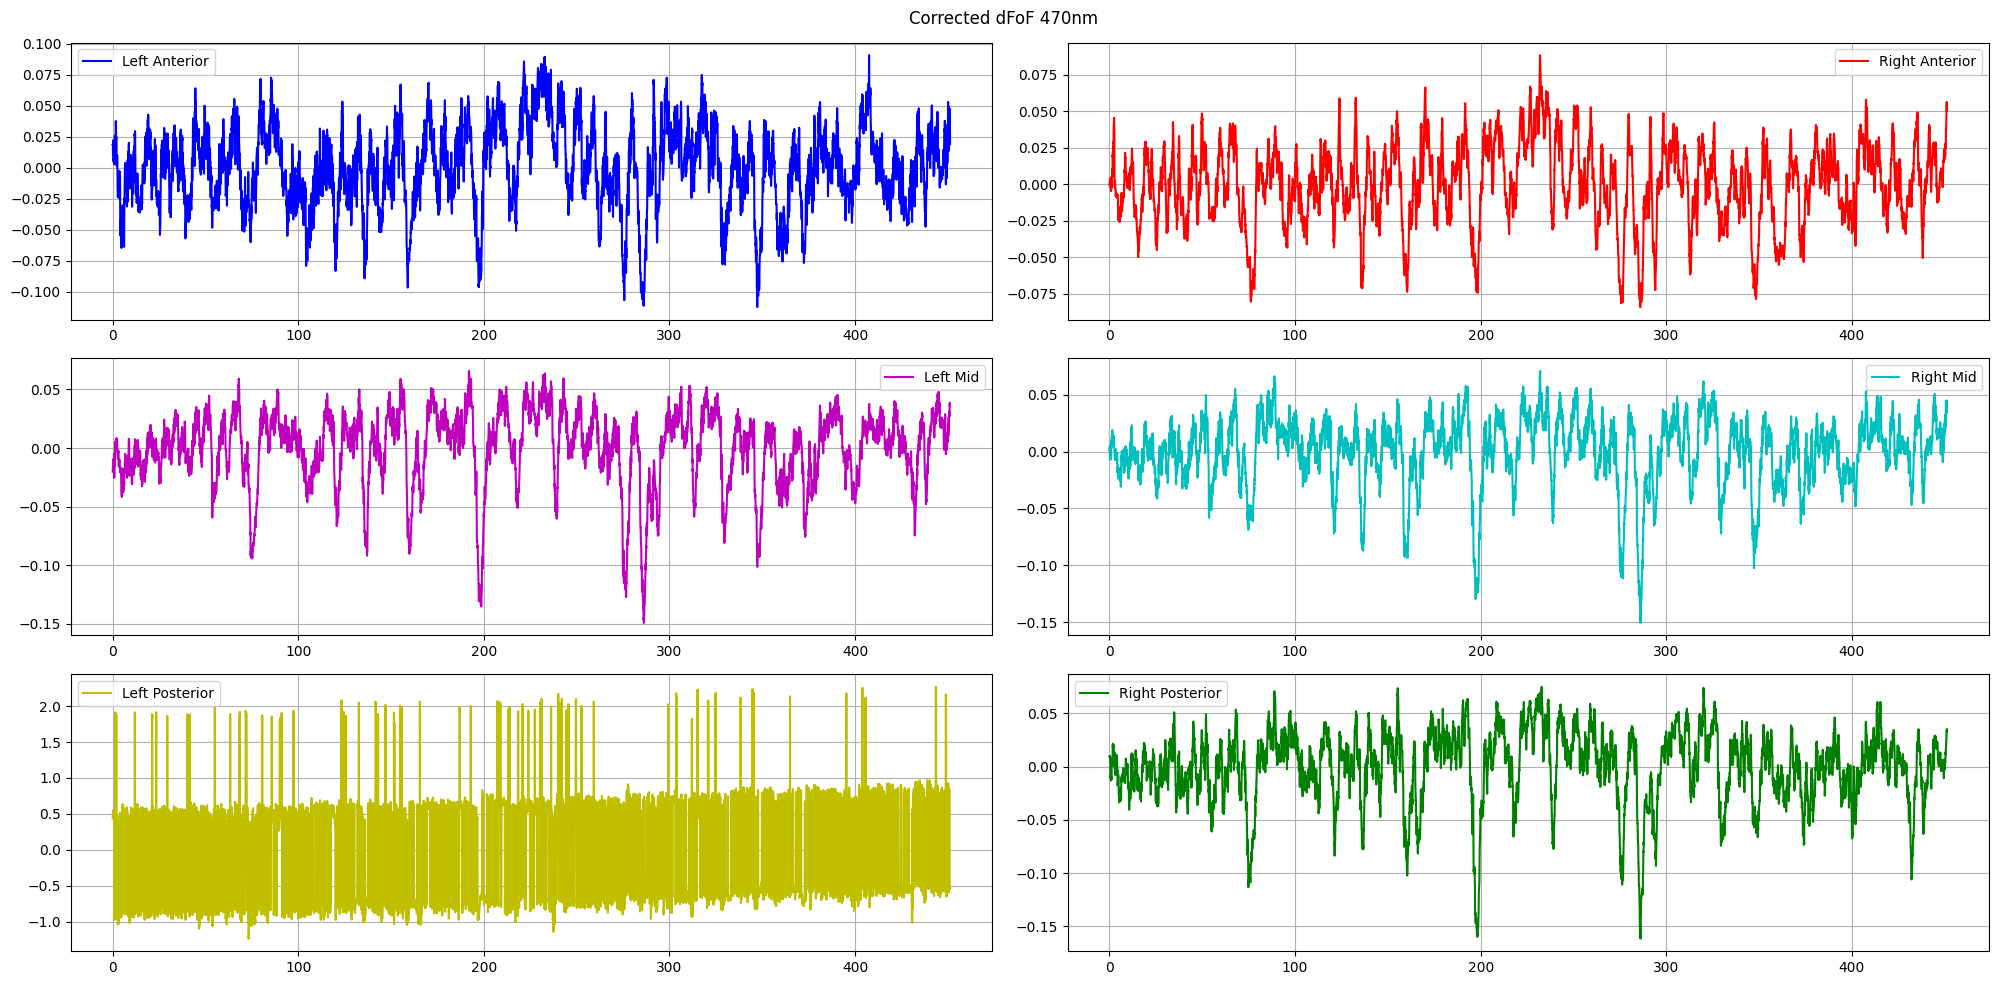

In [94]:
fig, ax = plt.subplots(3, 2, figsize=(20, 10))
channel_indices = [5160, 5205, 9000, 7770, 12220, 10970]
colors = ['b', 'r', 'm', 'c', 'y', 'g']
labels = ['Left Anterior', 'Right Anterior', 'Left Mid', 'Right Mid', 'Left Posterior', 'Right Posterior']
xlim_range = (25, 50) 

for i in range(3):
    for j in range(2):
        idx = i * 2 + j
        ax[i, j].plot(t_2[mask] - offset, dFoF_470_corrected[:, channel_indices[idx]][mask], colors[idx], label=labels[idx])
        # ax[i, j].plot(logic_t[logic_mask] - stim_start_time, (logic_array[:, 2][logic_mask]) * 0.03 - 0.015, 'k')
        ax[i, j].grid(True)
        ax[i, j].legend()
        # ax[i, j].set_xlim(xlim_range)

fig.suptitle('Corrected dFoF 470nm')

plt.tight_layout()
plt.show()

**Cell 13:** Plotting instructions to see the detrended dFoF 470nm and fitted 405nm signals for various locations across the brain for comparison.

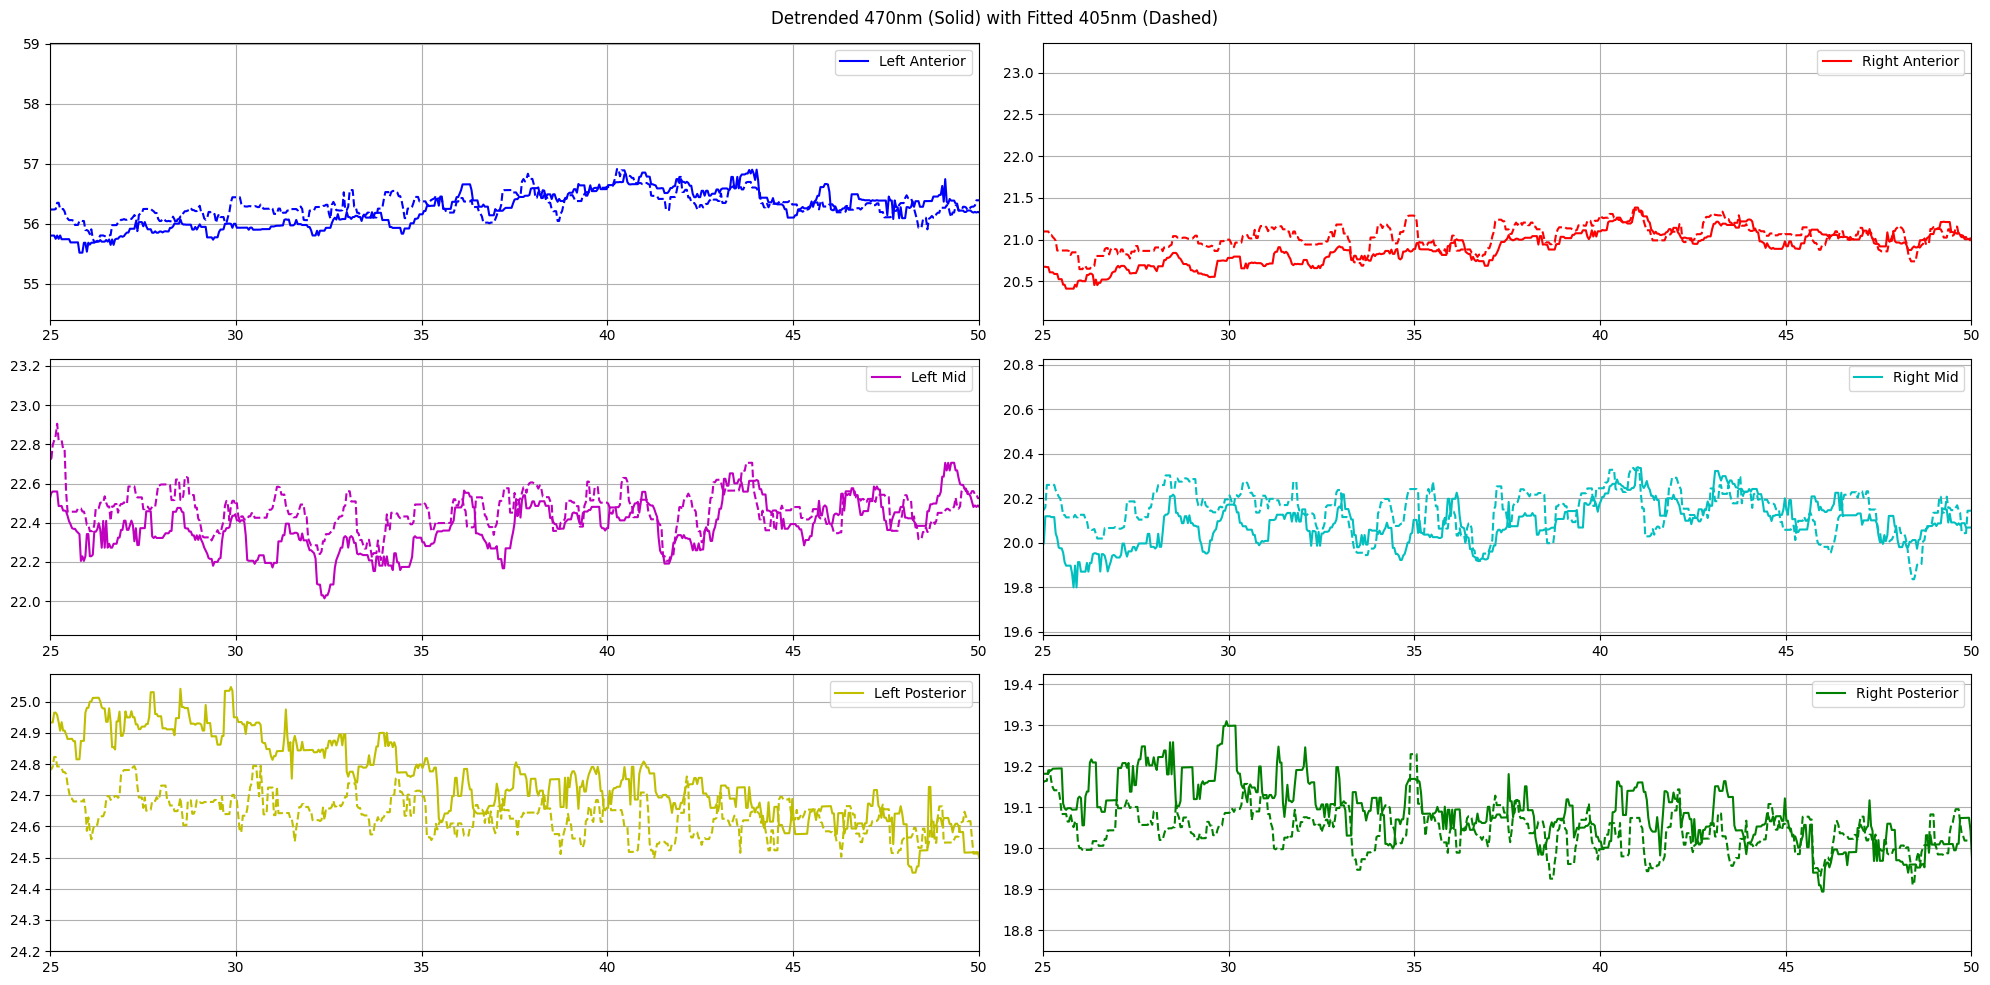

In [92]:
fig, ax = plt.subplots(3, 2, figsize=(20, 10))
channel_indices = [5160, 5205, 9000, 7770, 12220, 10970]
colors = ['b', 'r', 'm', 'c', 'y', 'g']
labels = ['Left Anterior', 'Right Anterior', 'Left Mid', 'Right Mid', 'Left Posterior', 'Right Posterior']
xlim_range = (25, 50) 

for i in range(3):
    for j in range(2):
        idx = i * 2 + j
        ax[i, j].plot(t_2[mask] - offset, detrended_470[:, channel_indices[idx]][mask] + F0[channel_indices[idx]], colors[idx], label=labels[idx])
        ax[i, j].plot(t_2[mask] - offset, fitted_405[:, channel_indices[idx]][mask], colors[idx], linestyle='--')
        #ax[i, j].plot(logic_t[logic_mask] - stim_start_time, logic_array[:, 2][logic_mask] * 0.75 - 0.5, 'k')
        ax[i, j].grid(True)
        ax[i, j].legend()
        ax[i, j].set_xlim(xlim_range)

fig.suptitle('Detrended 470nm (Solid) with Fitted 405nm (Dashed)')

plt.tight_layout()
plt.show()

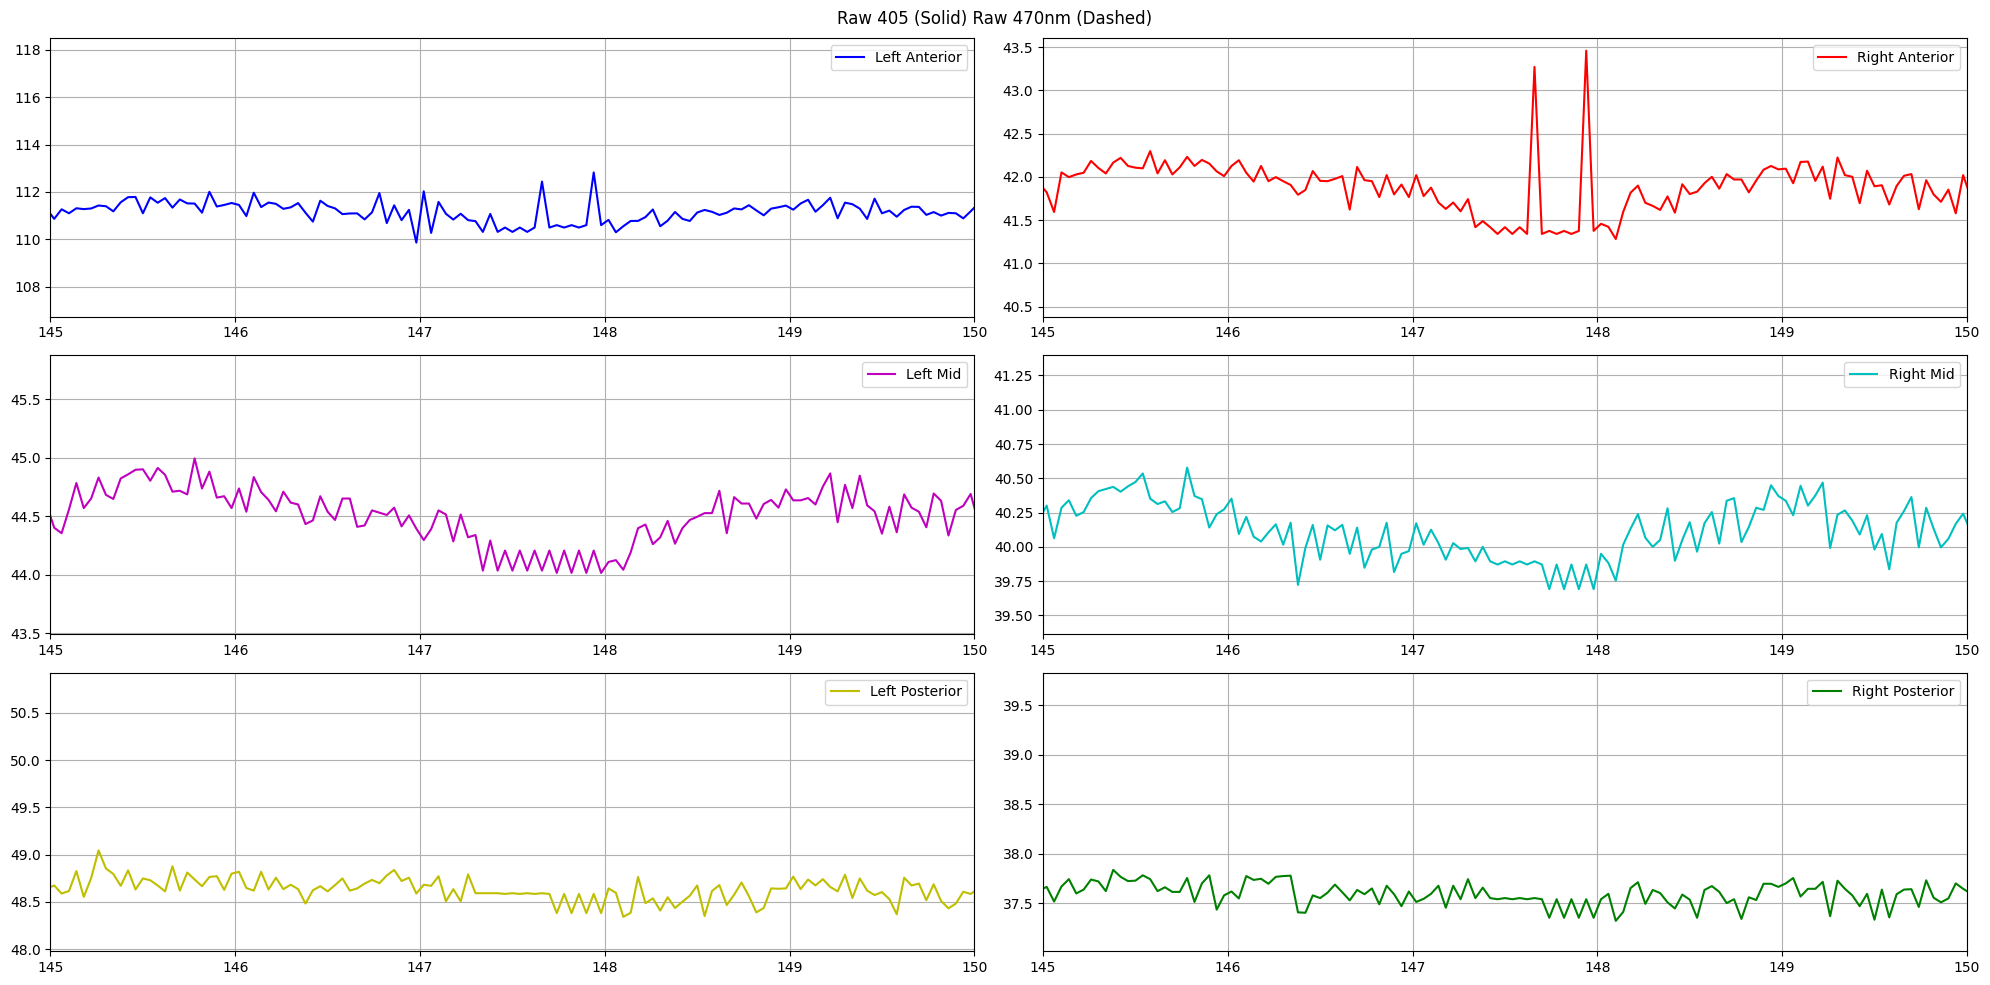

In [88]:
fig, ax = plt.subplots(3, 2, figsize=(20, 10))
channel_indices = [5160, 5205, 9000, 7770, 12220, 10970]
colors = ['b', 'r', 'm', 'c', 'y', 'g']
labels = ['Left Anterior', 'Right Anterior', 'Left Mid', 'Right Mid', 'Left Posterior', 'Right Posterior']
xlim_range = (145, 150) 

for i in range(3):
    for j in range(2):
        idx = i * 2 + j
        ax[i, j].plot(t_2 - offset, F_470[:, channel_indices[idx]] + F0[channel_indices[idx]], colors[idx], label=labels[idx])
        # ax[i, j].plot(t_2 - offset, F_405_raw[:, channel_indices[idx]], colors[idx], linestyle='--')
        ax[i, j].grid(True)
        ax[i, j].legend()
        ax[i, j].set_xlim(xlim_range)

fig.suptitle('Raw 405 (Solid) Raw 470nm (Dashed)')

plt.tight_layout()
plt.show()

(5008, 16384)
